In [ ]:
import pandas as pd

df = pd.read_csv("/content/Default_Fin.csv")

In [ ]:
df.head()

,Index,Employed,Bank Balance,Annual Salary,Defaulted?
0,1,1,8754.36,532339.56,0
1,2,0,9806.16,145273.56,0
2,3,1,12882.60,381205.68,0
3,4,1,6351.00,428453.88,0
4,5,1,9427.92,461562.00,0


In [ ]:
df.shape

(10000, 5)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          10000 non-null  int64  
 1   Employed       10000 non-null  int64  
 2   Bank Balance   10000 non-null  float64
 3   Annual Salary  10000 non-null  float64
 4   Defaulted?     10000 non-null  int64  
dtypes: float64(2), int64(3)
memory usage: 390.8 KB


In [ ]:
df.describe()

,Index,Employed,Bank Balance,Annual Salary,Defaulted?
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,0.705600,10024.498524,402203.782224,0.033300
std,2886.89568,0.455795,5804.579486,160039.674988,0.179428
min,1.00000,0.000000,0.000000,9263.640000,0.000000
25%,2500.75000,0.000000,5780.790000,256085.520000,0.000000
50%,5000.50000,1.000000,9883.620000,414631.740000,0.000000
75%,7500.25000,1.000000,13995.660000,525692.760000,0.000000
max,10000.00000,1.000000,31851.840000,882650.760000,1.000000


In [ ]:
df.isnull().sum()

,0
Index,0
Employed,0
Bank Balance,0
Annual Salary,0
Defaulted?,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.columns

Index(['Index', 'Employed', 'Bank Balance', 'Annual Salary', 'Defaulted?'], dtype='object')

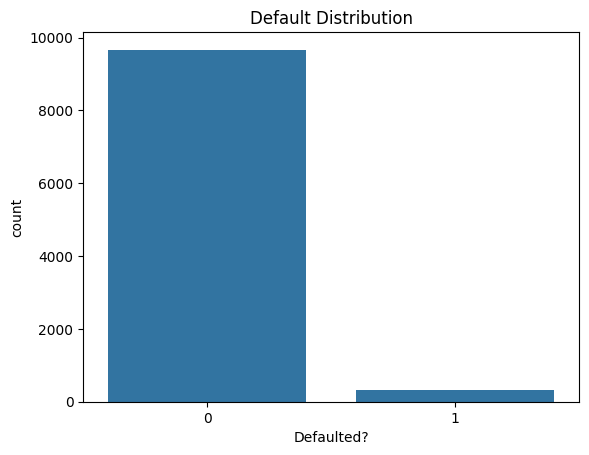

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Defaulted?', data=df)
plt.title("Default Distribution")
plt.show()

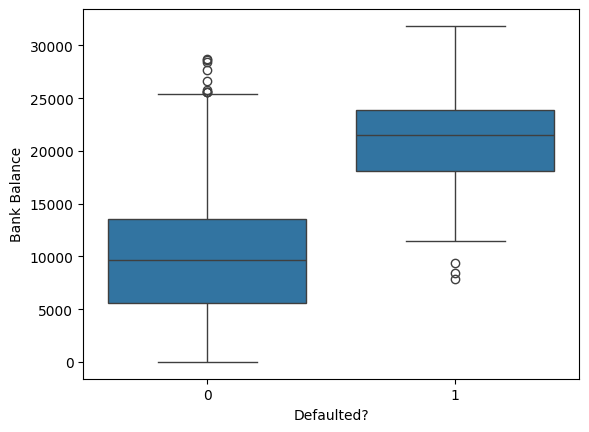

In [ ]:
sns.boxplot(x='Defaulted?', y='Bank Balance', data=df)
plt.show()

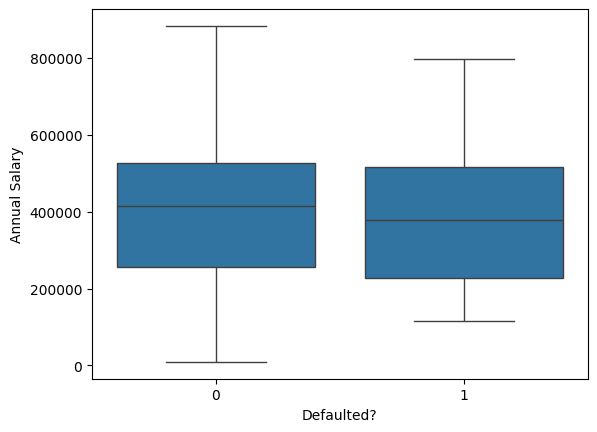

In [ ]:
sns.boxplot(x='Defaulted?', y='Annual Salary', data=df)
plt.show()

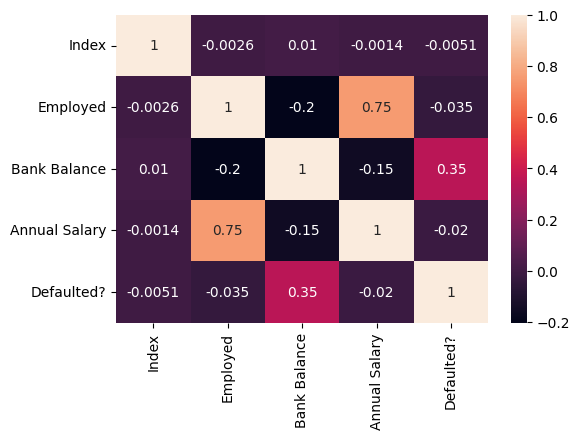

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True)
plt.show()

# Machine Learning

In [ ]:
X = df.drop("Defaulted?", axis=1)
y = df["Defaulted?"]

In [ ]:
print(X.columns)

Index(['Index', 'Employed', 'Bank Balance', 'Annual Salary'], dtype='object')


In [ ]:
print(df.columns)

Index(['Index', 'Employed', 'Bank Balance', 'Annual Salary', 'Defaulted?'], dtype='object')


In [ ]:
df.drop("Index", axis=1, inplace=True)

In [ ]:
print(df.columns)

Index(['Employed', 'Bank Balance', 'Annual Salary', 'Defaulted?'], dtype='object')


In [ ]:
X = df.drop("Defaulted?", axis=1)
y = df["Defaulted?"]

print(X.columns)

Index(['Employed', 'Bank Balance', 'Annual Salary'], dtype='object')


In [ ]:
df.to_csv("loan_default_cleaned.csv", index=False)

In [ ]:
X = df.drop("Defaulted?", axis=1)
y = df["Defaulted?"]

In [ ]:
print(X.columns)
print(y.head())

Index(['Employed', 'Bank Balance', 'Annual Salary'], dtype='object')
0    0
1    0
2    0
3    0
4    0
Name: Defaulted?, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (8000, 3)
X_test : (2000, 3)
y_train: (8000,)
y_test : (2000,)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
scaler.fit_transform(X_train)

array([[ 0.64512003,  0.38108615,  0.03730782],
       [ 0.64512003, -1.59177456, -0.37009848],
       [ 0.64512003,  0.43919519,  0.540178  ],
       ...,
       [ 0.64512003, -0.23061619, -0.49558007],
       [-1.55009913, -1.38184353, -0.93727639],
       [ 0.64512003, -0.40531461,  1.20145382]])

In [ ]:
scaler.transform(X_test)

array([[ 0.64512003,  1.24145887, -0.15705619],
       [ 0.64512003, -0.12797132,  0.63872411],
       [ 0.64512003, -1.72001876, -0.88292042],
       ...,
       [ 0.64512003, -1.66370435, -0.64029305],
       [-1.55009913,  1.06261422, -0.95319877],
       [ 0.64512003, -1.10381952,  1.19610071]])

In [ ]:
print(X_train[:5])

[[ 0.64512003  0.38108615  0.03730782]
 [ 0.64512003 -1.59177456 -0.37009848]
 [ 0.64512003  0.43919519  0.540178  ]
 [ 0.64512003 -0.14457685  0.7874205 ]
 [-1.55009913 -0.28173234 -0.58938981]]


In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = lr.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9695

Confusion Matrix:
[[1920   11]
 [  50   19]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1931
           1       0.63      0.28      0.38        69

    accuracy                           0.97      2000
   macro avg       0.80      0.63      0.68      2000
weighted avg       0.96      0.97      0.96      2000



In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_rf = rf.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.9645

Confusion Matrix:
[[1909   22]
 [  49   20]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1931
           1       0.48      0.29      0.36        69

    accuracy                           0.96      2000
   macro avg       0.73      0.64      0.67      2000
weighted avg       0.96      0.96      0.96      2000



In [ ]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

print(importance)

         Feature  Importance
1   Bank Balance    0.677561
2  Annual Salary    0.317076
0       Employed    0.005363


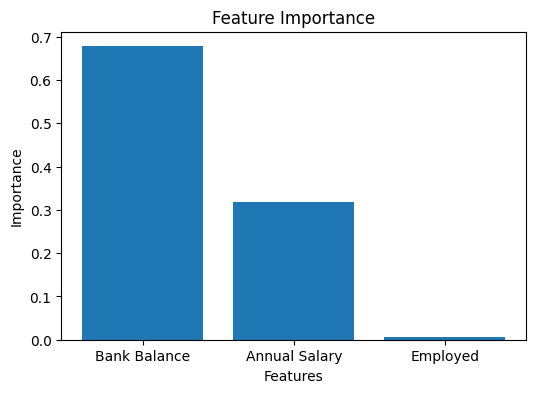

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(importance["Feature"], importance["Importance"])
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance")
plt.show()

In [ ]:
import joblib

joblib.dump(rf, "loan_default_model.pkl")

['loan_default_model.pkl']

In [ ]:
print(df.columns)

Index(['Employed', 'Bank Balance', 'Annual Salary', 'Defaulted?'], dtype='object')


In [ ]:
df.head()

,Employed,Bank Balance,Annual Salary,Defaulted?
0,1,8754.36,532339.56,0
1,0,9806.16,145273.56,0
2,1,12882.60,381205.68,0
3,1,6351.00,428453.88,0
4,1,9427.92,461562.00,0


In [ ]:
df.to_csv("loan_default_cleaned.csv", index=False)

In [ ]:
from google.colab import files
files.download("loan_default_cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>